# CSE 438 · Part B — MAE → DeepLabV3 (LiTS liver+tumour, 3-class)

**Group 01 · Dept. of CSE, East West University** — Md. Asif Hossain (2022-3-60-007) · Nabil Subhan (2022-3-60-063) · K M Nudar (2022-3-60-234)

**Pipeline:** ImageNet-init **ResNet-50** → **MAE** masked reconstruction (50 ep, Part-A *train* split, images only) → transfer encoder into **DeepLabV3** → fine-tune (50 ep) on the labelled **val** split → evaluate on **test**. Attach **LiTS 256×256** + **Part-B data-prep output**.

In [1]:
# ===== Setup, CUDA probe, AMP, config =====
import os, re, json, time, math, random, copy, warnings
from pathlib import Path
from contextlib import nullcontext
import numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.segmentation import deeplabv3_resnet50
from tqdm.auto import tqdm
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
CONFIG = dict(ssl_epochs=50, seg_epochs=50, ssl_batch=64, seg_batch=8, ssl_size=224, seg_size=256,
              num_classes=3, ssl_lr=3e-4, seg_lr=1e-4, weight_decay=1e-2, ema_base=0.996,
              mask_ratio=0.75, mask_patch=16, ce_weights=[0.3, 1.0, 6.0], method="mae")
CLASS_NAMES = ["background", "liver", "tumor"]
IMAGENET_MEAN = (0.485, 0.456, 0.406); IMAGENET_STD = (0.229, 0.224, 0.225)
WORK = Path("/kaggle/working"); WORK.mkdir(exist_ok=True)

def select_device():
    if not torch.cuda.is_available():
        print("CUDA unavailable -> CPU."); return torch.device("cpu"), False
    try:
        x = torch.randn(2,3,32,32,device="cuda"); l = nn.Conv2d(3,8,3,padding=1).to("cuda")
        l(x).float().mean().backward(); torch.cuda.synchronize()
        print("CUDA probe passed:", torch.cuda.get_device_name(0)); return torch.device("cuda"), True
    except Exception as e:
        print("CUDA probe failed:", type(e).__name__, "-> CPU."); return torch.device("cpu"), False
device, AMP = select_device()
SCALER = torch.amp.GradScaler("cuda", enabled=AMP)
def amp_ctx(): return torch.autocast("cuda", dtype=torch.float16) if AMP else nullcontext()
print("device", device, "| AMP", AMP); print("CONFIG", json.dumps(CONFIG))

# ---- version pins (PDF §4 item 1: "setup & imports with version pins") ----
import torch as _t, numpy as _n, pandas as _p
try: import albumentations as _a; _av = _a.__version__
except Exception: _av = "n/a"
try: import transformers as _tr; _tv = _tr.__version__
except Exception: _tv = "n/a"
print(f"torch {_t.__version__} | numpy {_n.__version__} | pandas {_p.__version__} "
      f"| albumentations {_av} | transformers {_tv}")

CUDA probe passed: Tesla T4
device cuda | AMP True
CONFIG {"ssl_epochs": 50, "seg_epochs": 50, "ssl_batch": 64, "seg_batch": 8, "ssl_size": 224, "seg_size": 256, "num_classes": 3, "ssl_lr": 0.0003, "seg_lr": 0.0001, "weight_decay": 0.01, "ema_base": 0.996, "mask_ratio": 0.75, "mask_patch": 16, "ce_weights": [0.3, 1.0, 6.0], "method": "mae"}
torch 2.10.0+cu128 | numpy 2.0.2 | pandas 2.3.3 | albumentations 2.0.8 | transformers 5.0.0


In [2]:
# ===== VIZ — validated palette + figure style =====
# Palette validated with the dataviz validator (light, surface #ffffff, --pairs all):
#   4 series  #2a78d6/#eb6834/#1baf7a/#4a3aa7 -> CVD dE 9.2, normal dE 16.3  ALL PASS
#   mask      liver #eda100 vs tumor #e34948  -> CVD dE 15.3, normal dE 20.8 ALL PASS
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
try:
    from IPython.display import display
except Exception:
    display = print

C_BLUE, C_ORANGE, C_AQUA, C_VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
C_YELLOW, C_RED = "#eda100", "#e34948"
INK, INK2, MUTED, GRIDC, RULE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
# colour follows the ENTITY, never its rank — a filtered chart never repaints survivors
METHOD_COLORS = {"SimCLR": C_BLUE, "BYOL": C_ORANGE, "MAE": C_AQUA, "DINOv2": C_VIOLET}
CLASS_COLORS  = ["#000000", C_YELLOW, C_RED]          # background / liver / tumour
cmap = ListedColormap(CLASS_COLORS)
CLASS_LEGEND = [Patch(facecolor=C_YELLOW, label="liver"), Patch(facecolor=C_RED, label="tumour")]
# error map: identity carried by legend + label, never colour alone (CVD warn band)
ERR_COLORS = {"correct": "#141413", "liver_err": C_YELLOW, "tumor_fn": C_RED, "tumor_fp": C_AQUA}
ERR_LEGEND = [Patch(facecolor=C_RED,    label="tumour missed (FN)"),
              Patch(facecolor=C_AQUA,   label="tumour false-positive (FP)"),
              Patch(facecolor=C_YELLOW, label="liver error")]

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "font.family": "sans-serif",
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.titlepad": 10,
    "axes.labelcolor": INK2, "axes.labelsize": 9.5, "axes.labelpad": 6,
    "axes.edgecolor": RULE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRIDC, "grid.linewidth": 0.7, "grid.alpha": 1.0,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "lines.linewidth": 2.0, "lines.markersize": 5,
})

def _fmt_df(df, fmt=None):
    """Per-column formatting: ints get thousands separators, floats 4dp unless overridden."""
    fmt = fmt or {}
    d = df.copy()
    for c in d.columns:
        k = d[c].dtype.kind
        f = fmt.get(c) if isinstance(fmt, dict) else None
        if f is None and k in "iu": f = "{:,.0f}"
        if f is None and k == "f":  f = "{:,.0f}" if d[c].dropna().gt(1000).all() else "{:.4f}"
        if f: d[c] = d[c].map(lambda v, f=f: "—" if pd.isna(v) else f.format(v))
    return d.astype(str)

def styled_table(df, title="", best=None, fmt=None):
    """Publication-style HTML table (Kaggle renders pandas Styler natively)."""
    fmt = fmt or {}
    spec = {}
    for c in df.columns:
        k = df[c].dtype.kind
        if c in fmt: spec[c] = fmt[c]
        elif k in "iu": spec[c] = "{:,.0f}"
        elif k == "f": spec[c] = "{:.4f}"
    txt = [c for c in df.columns if df[c].dtype.kind not in "iuf"]
    s = (df.style.format(spec, na_rep="—").hide(axis="index").set_caption(title)
         .set_properties(subset=txt, **{"text-align": "left"})
         .set_table_styles([
            {"selector": "caption", "props": [("caption-side","top"),("font-weight","700"),
                ("font-size","12.5pt"),("padding","4px 0 10px"),("color",INK),("text-align","left")]},
            {"selector": "th", "props": [("background","#f0efec"),("color",INK),("font-weight","600"),
                ("text-align","right"),("padding","7px 12px"),("border","none"),
                ("border-bottom",f"1.5px solid {RULE}"),("white-space","nowrap")]},
            {"selector": "td", "props": [("text-align","right"),("padding","7px 12px"),("border","none"),
                ("font-variant-numeric","tabular-nums"),("color",INK),("white-space","nowrap")]},
            {"selector": "tbody tr:nth-child(even)", "props": [("background","#fafaf8")]},
            {"selector": "", "props": [("border-collapse","collapse"),("font-size","10.5pt")]},
         ]))
    for c in ([best] if isinstance(best, str) else (best or [])):
        if c in df.columns and df[c].dtype.kind == "f":
            s = s.highlight_max(subset=[c], props="background:#dff0e4;font-weight:700;")
    return s

def table_png(df, path, title="", best=None, fmt=None):
    """Report-ready PNG of the same table. Column widths follow content so nothing clips."""
    d = _fmt_df(df, fmt)
    widths = np.array([max(len(str(c)), *(len(v) for v in d[c])) for c in d.columns], float)
    widths = widths / widths.sum()
    fig_w = min(15.0, 1.05 * sum(max(len(str(c)), *(len(v) for v in d[c])) for c in d.columns) * 0.115 + 1.2)
    fig, ax = plt.subplots(figsize=(max(7.0, fig_w), 0.62 + 0.40 * len(d)))
    ax.axis("off"); ax.set_xmargin(0); ax.set_ymargin(0)
    t = ax.table(cellText=d.values, colLabels=list(d.columns), loc="center",
                 cellLoc="right", colWidths=list(widths))
    t.auto_set_font_size(False); t.set_fontsize(9.5); t.scale(1, 1.5)
    txt_idx = [i for i, c in enumerate(df.columns) if df[c].dtype.kind not in "iuf"]
    bi = {}
    for c in ([best] if isinstance(best, str) else (best or [])):
        if c in df.columns and df[c].dtype.kind == "f":
            bi[list(df.columns).index(c)] = int(df[c].idxmax())
    for (r, c), cell in t.get_celld().items():
        cell.set_linewidth(0)
        if c in txt_idx: cell._loc = "left"
        if r == 0:
            cell.set_facecolor("#f0efec"); cell.set_text_props(weight="bold", color=INK)
            cell.visible_edges = "B"; cell.set_edgecolor(RULE); cell.set_linewidth(1.4)
        else:
            cell.set_facecolor("#fafaf8" if r % 2 == 0 else "white")
            if c in bi and r - 1 == bi[c]:
                cell.set_facecolor("#dff0e4"); cell.set_text_props(weight="bold")
    if title: ax.set_title(title, fontweight="bold", fontsize=12, loc="left", pad=10)
    plt.savefig(path); plt.show()
print("VIZ ready — validated palette, publication table styles, figure defaults.")

VIZ ready — validated palette, publication table styles, figure defaults.


## 1. Split roles + LiTS loaders

In [3]:
# ===== load partB_split_roles.json + raw LiTS + 2.5D loaders =====
roles_paths = list(Path("/kaggle/input").rglob("partB_split_roles.json"))
assert roles_paths, "Attach the Part-B data-prep output (partB_split_roles.json)."
roles_meta = json.load(open(roles_paths[0])); roles = roles_meta["roles"]
print("roles:", {k: len(v) for k, v in roles.items()})
imgdir = Path(roles_meta["dirs"]["images"])
if imgdir.exists():
    IMG_DIR, LIVER_DIR, TUMOR_DIR = imgdir, Path(roles_meta["dirs"]["liver"]), Path(roles_meta["dirs"]["tumor"])
else:
    root = next(iter(Path("/kaggle/input").rglob("Thesis_data")), Path("/kaggle/input"))
    IMG_DIR   = next(p for p in root.iterdir() if p.is_dir() and "image" in p.name.lower())
    LIVER_DIR = next(p for p in root.iterdir() if p.is_dir() and "liver" in p.name.lower())
    TUMOR_DIR = next(p for p in root.iterdir() if p.is_dir() and "tumor" in p.name.lower())
def vskey(p):
    n = [int(x) for x in re.findall(r"\d+", Path(p).stem)]; return (n[0], n[1]) if len(n) >= 2 else (n[0], -1)
img_by = {vskey(p): p for p in IMG_DIR.glob("*.png")}
liv_by = {vskey(p): p for p in LIVER_DIR.glob("*.png")}
tum_by = {vskey(p): p for p in TUMOR_DIR.glob("*.png")}
def load_25d(vol, sl):
    c = np.array(Image.open(img_by[(vol, sl)]).convert("L"))
    p = img_by.get((vol, sl-1)); n = img_by.get((vol, sl+1))
    pp = np.array(Image.open(p).convert("L")) if p is not None else c
    nn_ = np.array(Image.open(n).convert("L")) if n is not None else c
    return np.stack([pp, c, nn_], axis=-1)
def fuse_label(vol, sl):
    liv = np.array(Image.open(liv_by[(vol, sl)]).convert("L")) > 0
    tum = np.array(Image.open(tum_by[(vol, sl)]).convert("L")) > 0
    lab = np.zeros(liv.shape, np.uint8); lab[liv] = 1; lab[tum] = 2; return lab
def parse_ids(ids): return [tuple(int(x) for x in s.split("_")) for s in ids]
print("images paired:", len(img_by))

roles: {'unlabelled_pretrain': 13447, 'labelled_finetune': 2553, 'eval_monitor_test': 3158}
images paired: 58638


## 2. Datasets

In [4]:
# ===== labelled + eval datasets (SSL dataset defined in the MAE cell) =====
pin = device.type == "cuda"
label_tf = A.Compose([
    A.HorizontalFlip(0.5), A.VerticalFlip(0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=0.06, rotate=(-15, 15), p=0.5),
    A.OneOf([A.ElasticTransform(alpha=40, sigma=6), A.GridDistortion(num_steps=5, distort_limit=0.2)], p=0.25),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.3), A.GaussNoise(p=0.2),
    A.Resize(CONFIG["seg_size"], CONFIG["seg_size"]),
    A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])
eval_tf = A.Compose([A.Resize(CONFIG["seg_size"], CONFIG["seg_size"]),
                     A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])
class LabelledDataset(Dataset):
    def __init__(self, ids, tf): self.ids = parse_ids(ids); self.tf = tf
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        v, s = self.ids[i]; o = self.tf(image=load_25d(v, s), mask=fuse_label(v, s)); return o["image"], o["mask"].long()
finetune_loader = DataLoader(LabelledDataset(roles["labelled_finetune"], label_tf), batch_size=CONFIG["seg_batch"],
                             shuffle=True, num_workers=2, pin_memory=pin, persistent_workers=True, drop_last=True)  # drop_last=True: 2553%8==1 would make a 1-image batch -> BatchNorm crash in ASPP pooling
test_loader = DataLoader(LabelledDataset(roles["eval_monitor_test"], eval_tf), batch_size=CONFIG["seg_batch"],
                         shuffle=False, num_workers=2, pin_memory=pin, persistent_workers=True, drop_last=False)
print("batches -> finetune", len(finetune_loader), "| test", len(test_loader))

batches -> finetune 319 | test 395


## 3. Stage A — MAE pretraining (50 epochs)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


ResNet-50 ImageNet init.


MAE 1/50:   0%|          | 0/420 [00:00<?, ?it/s]

  epoch 1: MAE recon 0.1517 | 110.4s


...

  epoch 48: MAE recon 0.0637 | 76.1s


MAE 49/50:   0%|          | 0/420 [00:00<?, ?it/s]

  epoch 49: MAE recon 0.0636 | 85.6s


MAE 50/50:   0%|          | 0/420 [00:00<?, ?it/s]

  epoch 50: MAE recon 0.0634 | 91.7s
mean sec/epoch: 81.8


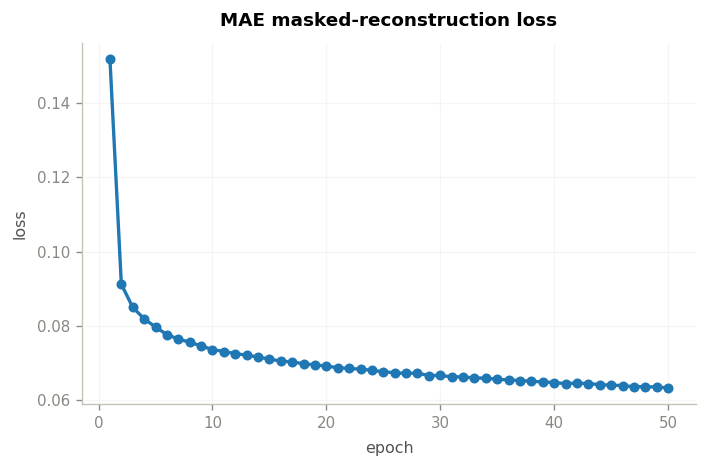

In [5]:
# ===== MAE: ResNet-50 CNN masked-autoencoder (50-epoch pretraining) =====
def make_encoder():
    try: e = resnet50(weights=ResNet50_Weights.DEFAULT); print("ResNet-50 ImageNet init.")
    except Exception as ex: print("no imagenet:", ex); e = resnet50(weights=None)
    e.fc = nn.Identity(); return e
def resnet_spatial(enc, x):
    x = enc.conv1(x); x = enc.bn1(x); x = enc.relu(x); x = enc.maxpool(x)
    x = enc.layer1(x); x = enc.layer2(x); x = enc.layer3(x); return enc.layer4(x)
class ReconDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.d = nn.Sequential(
            nn.ConvTranspose2d(2048,512,2,2), nn.BatchNorm2d(512), nn.GELU(),
            nn.ConvTranspose2d(512,256,2,2), nn.BatchNorm2d(256), nn.GELU(),
            nn.ConvTranspose2d(256,128,2,2), nn.BatchNorm2d(128), nn.GELU(),
            nn.ConvTranspose2d(128,64,2,2), nn.BatchNorm2d(64), nn.GELU(),
            nn.ConvTranspose2d(64,3,2,2))
    def forward(self, x): return torch.sigmoid(self.d(x))
class ResNetMAE(nn.Module):
    def __init__(self): super().__init__(); self.encoder = make_encoder(); self.decoder = ReconDecoder()
    def forward(self, x): return self.decoder(resnet_spatial(self.encoder, x))
def create_patch_mask(x, patch=CONFIG["mask_patch"], ratio=CONFIG["mask_ratio"]):
    B, _, H, W = x.shape; gh, gw = H//patch, W//patch; n = gh*gw; k = max(1, int(round(n*ratio)))
    ids = torch.rand(B, n, device=x.device).argsort(1)[:, :k]
    pm = torch.zeros(B, n, device=x.device); pm.scatter_(1, ids, 1.0)
    pm = pm.view(B,1,gh,gw).repeat_interleave(patch,2).repeat_interleave(patch,3)
    return (x*(1-pm)).contiguous(), pm.contiguous()
def masked_recon_loss(recon, target, mask, eps=1e-6):
    m = mask.expand_as(target).float(); d = recon.float() - target.float()
    return ((d.abs() + 0.2*d*d) * m).sum() / (m.sum() + eps)
mae_aug = A.Compose([A.RandomResizedCrop(size=(CONFIG["ssl_size"], CONFIG["ssl_size"]), scale=(0.5, 1.0)), A.HorizontalFlip(0.5)])
class MAEDataset(Dataset):
    def __init__(self, ids): self.ids = parse_ids(ids)
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        img = (load_25d(*self.ids[i]).astype(np.float32) / 255.0)
        aug = mae_aug(image=img)["image"]
        t = torch.from_numpy(aug).permute(2, 0, 1).float()
        norm = (t - torch.tensor(IMAGENET_MEAN).view(3,1,1)) / torch.tensor(IMAGENET_STD).view(3,1,1)
        return norm, t
mae_loader = DataLoader(MAEDataset(roles["unlabelled_pretrain"]), batch_size=32, shuffle=True,
                        num_workers=2, pin_memory=pin, persistent_workers=True, drop_last=True)
mae = ResNetMAE().to(device)
# DataParallel DISABLED: it re-replicates the model every forward pass and leaked host RAM ->
# SimCLR died @48/50 and MAE @45/50 with it ON, while BYOL (no DP) completed 50/50 and ran longer.
# It also gave almost no speedup here (DP scatter/gather overhead). Single-GPU is the stable path.
USE_DATA_PARALLEL = False
def unwrap(m): return m.module if isinstance(m, nn.DataParallel) else m
if USE_DATA_PARALLEL and torch.cuda.device_count() > 1:
    mae = nn.DataParallel(mae); print(f"DataParallel across {torch.cuda.device_count()} GPUs")
ssl_opt = torch.optim.AdamW(mae.parameters(), lr=CONFIG["ssl_lr"], weight_decay=CONFIG["weight_decay"])
ssl_hist = []
import gc
_cands = list(Path("/kaggle/input").rglob("mae_ssl_ckpt.pt")) + list(Path("/kaggle/working").rglob("mae_ssl_ckpt.pt"))
_ck = _cands[0] if _cands else None
START_EP, ssl_hist = 1, []
if _ck is not None:
    _st = torch.load(_ck, map_location=device)
    unwrap(mae).encoder.load_state_dict(_st["encoder"])
    try: ssl_opt.load_state_dict(_st["opt"])
    except Exception as _e: print("optimiser state not restored:", type(_e).__name__)
    START_EP = int(_st.get("epoch", 0)) + 1; ssl_hist = list(_st.get("hist", []))
    print(f"RESUMED from {_ck} -> continuing at epoch {START_EP}/{CONFIG['ssl_epochs']}")
else:
    _fin = list(Path("/kaggle/input").rglob("mae_resnet50_encoder.pt")) + list(Path("/kaggle/working").rglob("mae_resnet50_encoder.pt"))
    if _fin:
        unwrap(mae).encoder.load_state_dict(torch.load(_fin[0], map_location=device))
        START_EP = CONFIG["ssl_epochs"] + 1   # completed run -> loop is empty, go straight to fine-tuning
        print("Loaded COMPLETED 50-epoch SSL encoder from", _fin[0], "-> skipping pretraining.")
for ep in range(START_EP, CONFIG["ssl_epochs"] + 1):
    mae.train(); losses = []; t0 = time.time()
    for norm, target in tqdm(mae_loader, desc=f"MAE {ep}/{CONFIG['ssl_epochs']}", leave=False, mininterval=30.0):
        norm = norm.to(device, non_blocking=pin); target = target.to(device, non_blocking=pin)
        masked, pm = create_patch_mask(norm)
        ssl_opt.zero_grad(set_to_none=True)
        with amp_ctx(): recon = mae(masked); loss = masked_recon_loss(recon, target, pm)
        SCALER.scale(loss).backward(); SCALER.step(ssl_opt); SCALER.update(); losses.append(loss.item())
    ssl_hist.append({"epoch": ep, "loss": float(np.mean(losses)), "sec": round(time.time()-t0,1)})
    print(f"  epoch {ep}: MAE recon {ssl_hist[-1]['loss']:.4f} | {ssl_hist[-1]['sec']}s")
    _pl = {"epoch": ep, "encoder": unwrap(mae).encoder.state_dict(), "opt": ssl_opt.state_dict(), "hist": ssl_hist}
    torch.save(_pl, WORK/"mae_ssl_ckpt.pt")   # crash-safe: a dead kernel costs 1 epoch, not 48
    gc.collect(); torch.cuda.empty_cache()
ssl_df = pd.DataFrame(ssl_hist if ssl_hist else [{"epoch": 0, "loss": float("nan"), "sec": 0.0}]); ssl_df.to_csv(WORK/"mae_pretrain_history.csv", index=False)
pretrained_encoder = unwrap(mae).encoder; torch.save(pretrained_encoder.state_dict(), WORK/"mae_resnet50_encoder.pt")
print("mean sec/epoch:", round(ssl_df.sec.mean(),1))
plt.figure(figsize=(6,4)); plt.plot(ssl_df.epoch, ssl_df.loss, marker="o")
plt.title("MAE masked-reconstruction loss"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(WORK/"mae_pretrain_curve.png", dpi=140); plt.show()

## 4. Stage B — transfer to DeepLabV3 + 3-class metrics

In [6]:
# ===== DeepLabV3 (Part-A decoder) + transfer pretrained encoder + loss/metrics =====
seg = deeplabv3_resnet50(weights=None, weights_backbone=None, num_classes=CONFIG["num_classes"], aux_loss=True)
rep = seg.backbone.load_state_dict(pretrained_encoder.state_dict(), strict=False)
print("transferred encoder -> DeepLabV3 backbone | missing:", len(rep.missing_keys)); seg = seg.to(device)
ce_w = torch.tensor(CONFIG["ce_weights"], device=device)
def dice_loss(logits, tgt, eps=1.0):
    p = torch.softmax(logits, 1); oh = F.one_hot(tgt, CONFIG["num_classes"]).permute(0,3,1,2).float()
    inter = (p*oh).sum((0,2,3)); den = p.sum((0,2,3)) + oh.sum((0,2,3))
    return (1 - (2*inter+eps)/(den+eps)).mean()
def criterion(out, tgt):
    lg = out["out"].float(); loss = F.cross_entropy(lg, tgt, weight=ce_w) + dice_loss(lg, tgt)
    if out.get("aux") is not None: loss = loss + 0.4*F.cross_entropy(out["aux"].float(), tgt, weight=ce_w)
    return loss
class ConfMat:
    def __init__(self, n): self.n = n; self.mat = torch.zeros(n, n, dtype=torch.long)
    def update(self, pred, tgt):
        k = (tgt >= 0) & (tgt < self.n)
        self.mat += torch.bincount(self.n*tgt[k].long() + pred[k].long(), minlength=self.n**2).reshape(self.n, self.n).cpu()
    def metrics(self):
        m = self.mat.double(); tp = m.diag()
        iou = tp / (m.sum(1) + m.sum(0) - tp).clamp(min=1e-9)
        dice = 2*tp / (m.sum(1) + m.sum(0)).clamp(min=1e-9)
        return dict(mIoU=iou.mean().item(), per_class_iou=iou.tolist(), mean_dice=dice.mean().item(),
                    pixel_acc=(tp.sum()/m.sum().clamp(min=1e-9)).item(),
                    tumor_sensitivity=(m[2,2]/m[2,:].sum().clamp(min=1e-9)).item())
@torch.inference_mode()
def evaluate(model, loader):
    model.eval(); cm = ConfMat(CONFIG["num_classes"])
    for x, y in loader:
        x = x.to(device, non_blocking=pin)
        with amp_ctx(): out = model(x)["out"]
        cm.update(out.argmax(1).cpu(), y)
    return cm.metrics(), cm
print("DeepLabV3 ready.")

transferred encoder -> DeepLabV3 backbone | missing: 0
DeepLabV3 ready.


## 5. Stage B — fine-tune on val (50 ep), monitor on test

finetune 1/50:   0%|          | 0/319 [00:00<?, ?it/s]

  ep 1: loss 1.5187 | test mIoU 0.5477 | tumor IoU 0.0337


finetune 2/50:   0%|          | 0/319 [00:00<?, ?it/s]

  ep 2: loss 0.7777 | test mIoU 0.6834 | tumor IoU 0.2649


finetune 3/50:   0%|          | 0/319 [00:00<?, ?it/s]

...

  ep 48: loss 0.1197 | test mIoU 0.7130 | tumor IoU 0.2623


finetune 49/50:   0%|          | 0/319 [00:00<?, ?it/s]

  ep 49: loss 0.1189 | test mIoU 0.7116 | tumor IoU 0.2579


finetune 50/50:   0%|          | 0/319 [00:00<?, ?it/s]

  ep 50: loss 0.1173 | test mIoU 0.7091 | tumor IoU 0.2515
best test mIoU: 0.7205 | mean sec/epoch: 89.4


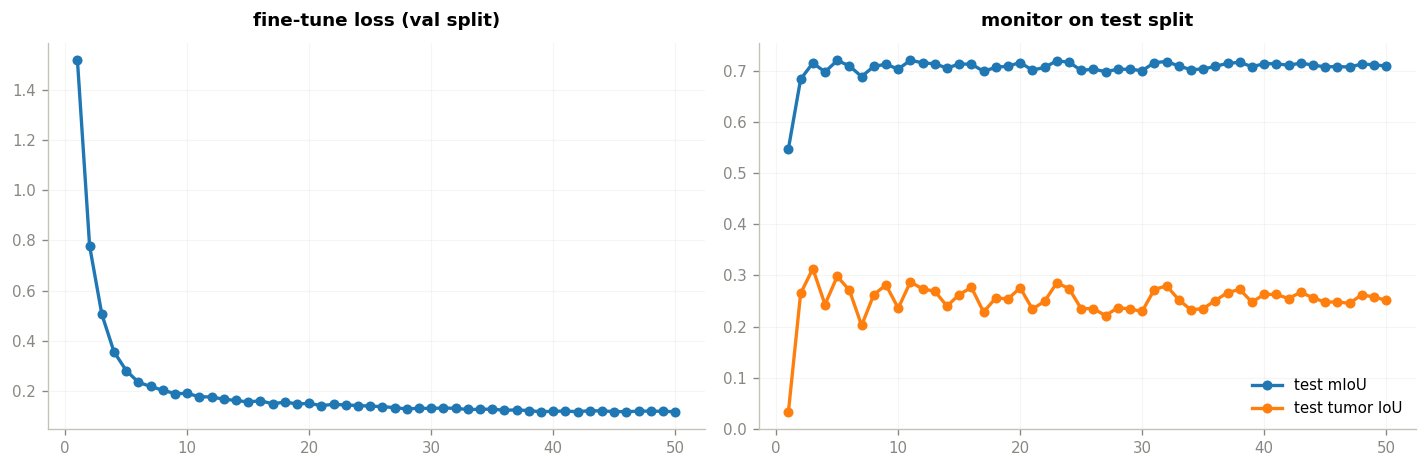

In [7]:
# ===== 50-epoch fine-tune on labelled val split; checkpoint by best TEST mIoU =====
seg_opt = torch.optim.AdamW(seg.parameters(), lr=CONFIG["seg_lr"], weight_decay=CONFIG["weight_decay"])
warm = torch.optim.lr_scheduler.LinearLR(seg_opt, start_factor=0.1, total_iters=3)
cos = torch.optim.lr_scheduler.CosineAnnealingLR(seg_opt, T_max=CONFIG["seg_epochs"]-3)
seg_sched = torch.optim.lr_scheduler.SequentialLR(seg_opt, [warm, cos], milestones=[3])
seg_hist, best_miou, best_state = [], -1.0, None
for ep in range(1, CONFIG["seg_epochs"]+1):
    seg.train(); tl = []; t0 = time.time()
    for x, y in tqdm(finetune_loader, desc=f"finetune {ep}/{CONFIG['seg_epochs']}", leave=False, mininterval=30.0):
        x = x.to(device, non_blocking=pin); y = y.to(device, non_blocking=pin).long()
        seg_opt.zero_grad(set_to_none=True)
        with amp_ctx(): out = seg(x)
        loss = criterion(out, y)
        SCALER.scale(loss).backward(); SCALER.step(seg_opt); SCALER.update(); tl.append(loss.item())
    seg_sched.step(); tm, _ = evaluate(seg, test_loader)
    seg_hist.append({"epoch": ep, "train_loss": float(np.mean(tl)), "test_mIoU": tm["mIoU"],
                     "test_tumor_iou": tm["per_class_iou"][2], "sec": round(time.time()-t0,1)})
    print(f"  ep {ep}: loss {seg_hist[-1]['train_loss']:.4f} | test mIoU {tm['mIoU']:.4f} | tumor IoU {tm['per_class_iou'][2]:.4f}")
    if tm["mIoU"] > best_miou: best_miou = tm["mIoU"]; best_state = copy.deepcopy({k: v.cpu() for k, v in seg.state_dict().items()})
seg.load_state_dict(best_state); seg.to(device)
seg_df = pd.DataFrame(seg_hist); seg_df.to_csv(WORK/"mae_finetune_history.csv", index=False)
print("best test mIoU:", round(best_miou,4), "| mean sec/epoch:", round(seg_df.sec.mean(),1))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(seg_df.epoch, seg_df.train_loss, marker="o"); ax[0].set_title("fine-tune loss (val split)"); ax[0].grid(alpha=.3)
ax[1].plot(seg_df.epoch, seg_df.test_mIoU, marker="o", label="test mIoU")
ax[1].plot(seg_df.epoch, seg_df.test_tumor_iou, marker="o", label="test tumor IoU")
ax[1].set_title("monitor on test split"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(WORK/"mae_finetune_curves.png", dpi=140); plt.show()

## 6. Test evaluation + confusion matrix

epoch-50 mIoU: 0.7091 | best-ckpt mIoU: 0.7205
{
  "mIoU": 0.7205,
  "per_class_iou": [
    0.992,
    0.8821,
    0.2873
  ],
  "mean_dice": 0.7932,
  "pixel_acc": 0.9906,
  "tumor_sensitivity": 0.3018
}


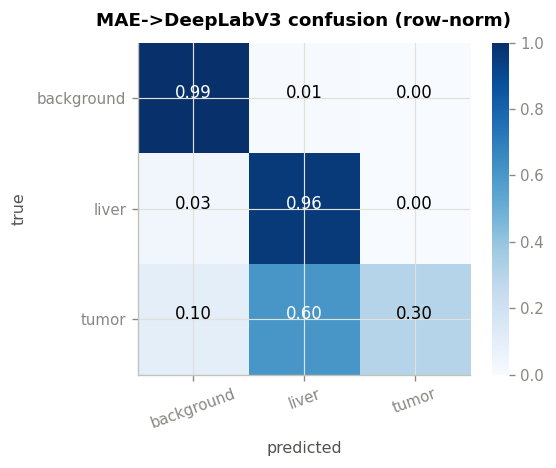

appended results.json -> ['mae']


In [8]:
# ===== final test metrics + confusion + append results.json =====
final, cm = evaluate(seg, test_loader)
print("epoch-50 mIoU:", round(seg_df.test_mIoU.iloc[-1],4), "| best-ckpt mIoU:", round(final["mIoU"],4))
print(json.dumps({k: (round(v,4) if isinstance(v,float) else [round(x,4) for x in v]) for k,v in final.items()}, indent=2))
m = cm.mat.double(); mn = (m / m.sum(1, keepdim=True).clamp(min=1e-9)).numpy()
plt.figure(figsize=(5,4)); plt.imshow(mn, cmap="Blues", vmin=0, vmax=1)
for i in range(3):
    for j in range(3): plt.text(j, i, f"{mn[i,j]:.2f}", ha="center", color="white" if mn[i,j] > .5 else "black")
plt.xticks(range(3), CLASS_NAMES, rotation=20); plt.yticks(range(3), CLASS_NAMES)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("MAE->DeepLabV3 confusion (row-norm)")
cb = plt.colorbar(); cb.outline.set_visible(False); plt.tight_layout(); plt.savefig(WORK/"mae_confusion.png", dpi=140); plt.show()
res_path = WORK/"results.json"; results = json.load(open(res_path)) if res_path.exists() else {}
results["mae"] = {"method": "MAE", "encoder": "ResNet-50 (ImageNet-init, 50ep SSL)", "decoder": "DeepLabV3 ASPP",
    "n_labelled_finetune": len(roles["labelled_finetune"]), "n_pretrain": len(roles["unlabelled_pretrain"]),
    "epoch50_test_mIoU": float(seg_df.test_mIoU.iloc[-1]), "best_ckpt": final, "seg_sec_per_epoch": float(seg_df.sec.mean())}
json.dump(results, open(res_path, "w"), indent=2); print("appended results.json ->", list(results.keys()))

## 7. Qualitative predictions

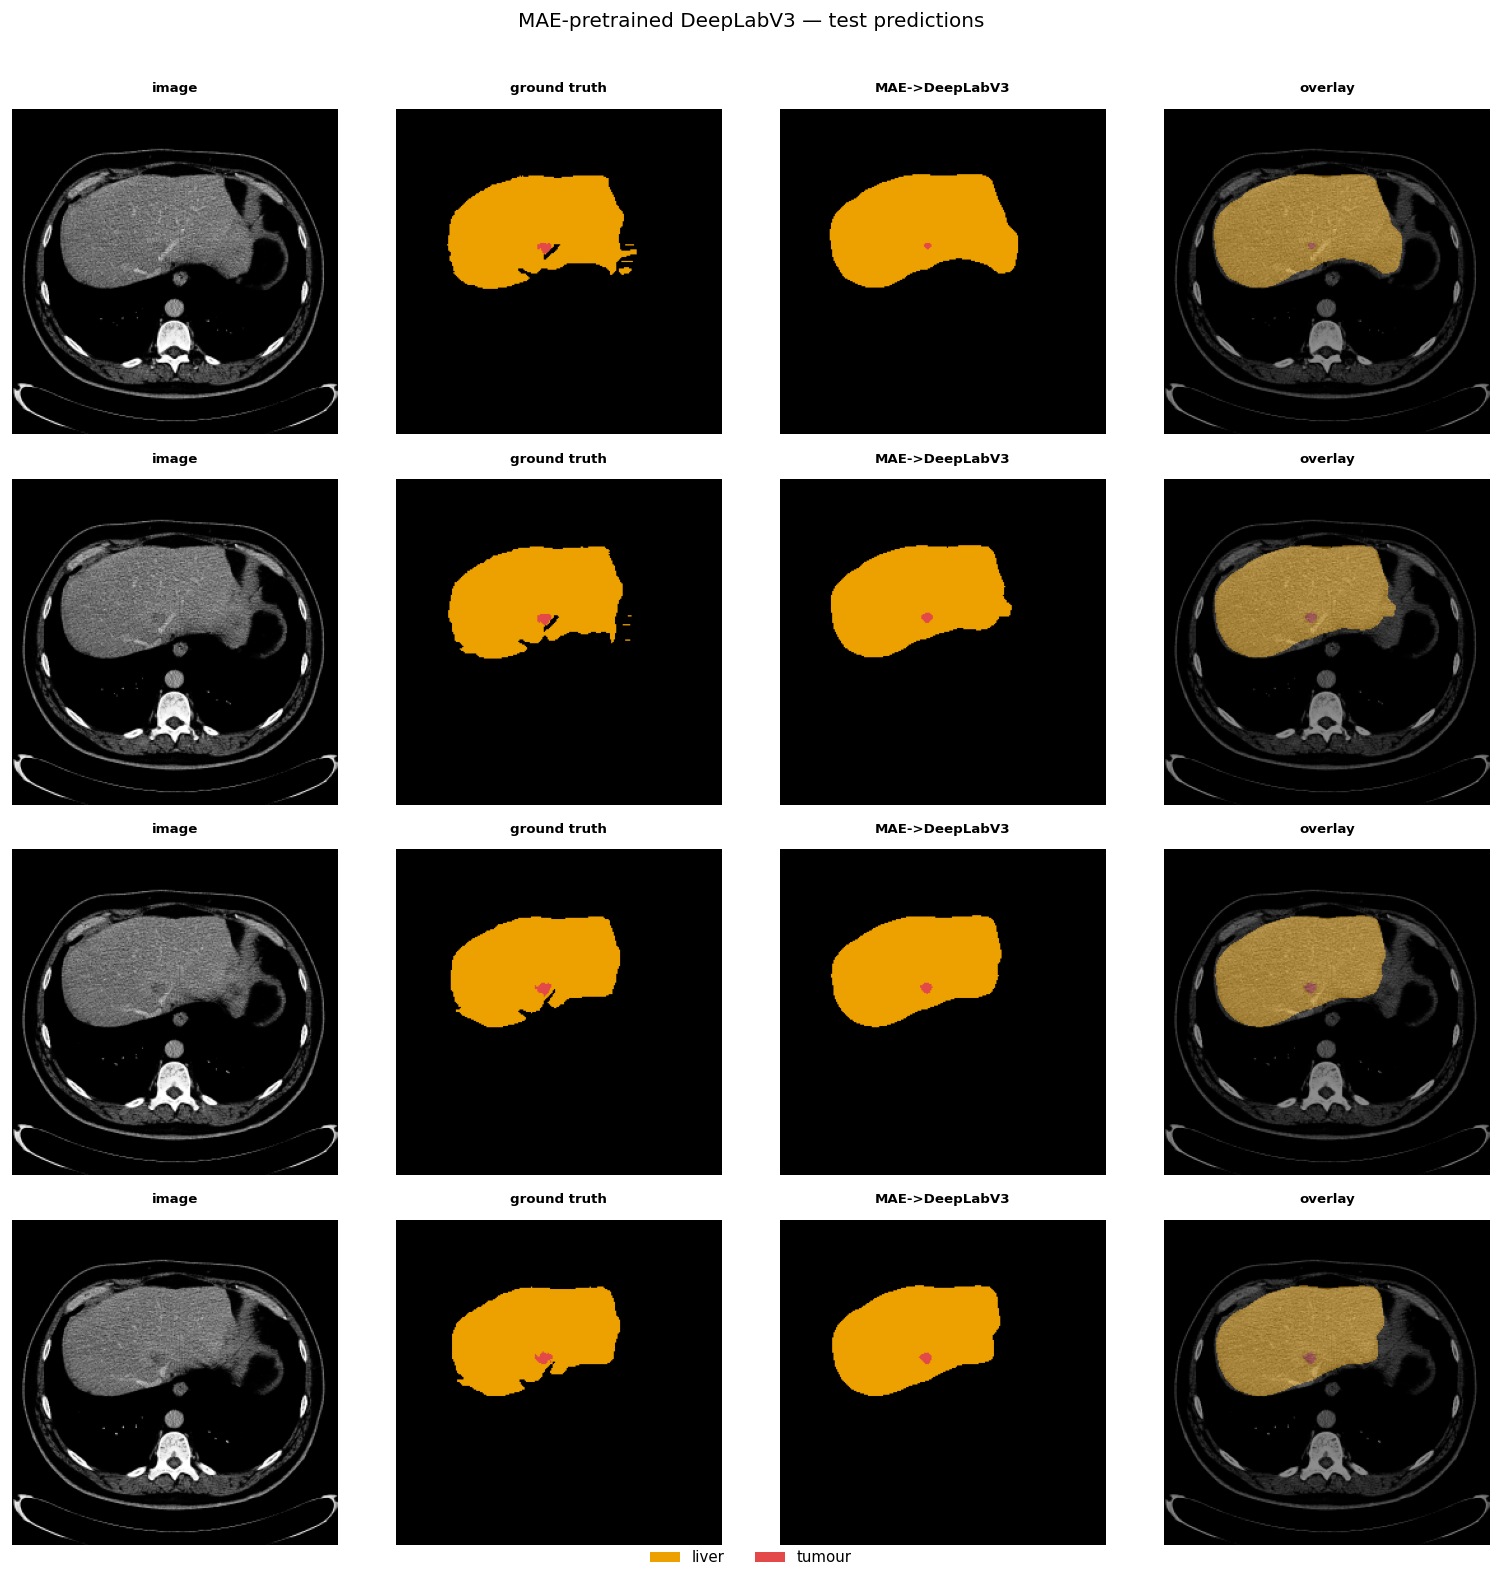

In [9]:
# ===== qualitative grid =====
# `cmap`, CLASS_LEGEND, ERR_* come from the VIZ block (validated palette)
def denorm(t): return np.clip(t.permute(1,2,0).numpy()*np.array(IMAGENET_STD)+np.array(IMAGENET_MEAN), 0, 1)
ds = LabelledDataset(roles["eval_monitor_test"][:200], eval_tf); picks = []
for i in range(len(ds)):
    _, y = ds[i]
    if (y == 2).sum() > 40: picks.append(i)
    if len(picks) == 4: break
picks = picks or list(range(4)); seg.eval()
fig, ax = plt.subplots(len(picks), 4, figsize=(13, 3.2*len(picks)))
for r, idx in enumerate(picks):
    x, y = ds[idx]
    with torch.inference_mode(), amp_ctx(): pr = seg(x.unsqueeze(0).to(device))["out"].argmax(1)[0].cpu().numpy()
    im = denorm(x)[..., 1]
    ax[r,0].imshow(im, cmap="gray"); ax[r,0].set_title("image", fontsize=8)
    ax[r,1].imshow(y.numpy(), cmap=cmap, vmin=0, vmax=2); ax[r,1].set_title("ground truth", fontsize=8)
    ax[r,2].imshow(pr, cmap=cmap, vmin=0, vmax=2); ax[r,2].set_title("MAE->DeepLabV3", fontsize=8)
    ax[r,3].imshow(im, cmap="gray"); ax[r,3].imshow(pr, cmap=cmap, vmin=0, vmax=2, alpha=.45); ax[r,3].set_title("overlay", fontsize=8)
    for c in range(4): ax[r,c].axis("off")
fig.legend(handles=CLASS_LEGEND, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.01))
plt.suptitle("MAE-pretrained DeepLabV3 — test predictions", y=1.01)
plt.tight_layout(); plt.savefig(WORK/"mae_qualitative.png", dpi=140); plt.show()

## 8. Task F — Error analysis (REQUIRED)

Per the assignment (§3.6): visualise the **worst-performing test images (lowest per-image IoU)** against ground
truth, and discuss whether errors concentrate on the **same** classes/images as the Part-A supervised models or on
**different** ones. Per-image scores are exported so the final-comparison notebook can compare failure sets across
all four SSL methods and against Part A.

per-image IoU:   0%|          | 0/395 [00:00<?, ?it/s]

per-image mIoU: mean 0.8367 | median 0.9291 | min 0.4877
tumour-bearing slices: 844 | mean tumour IoU 0.2225


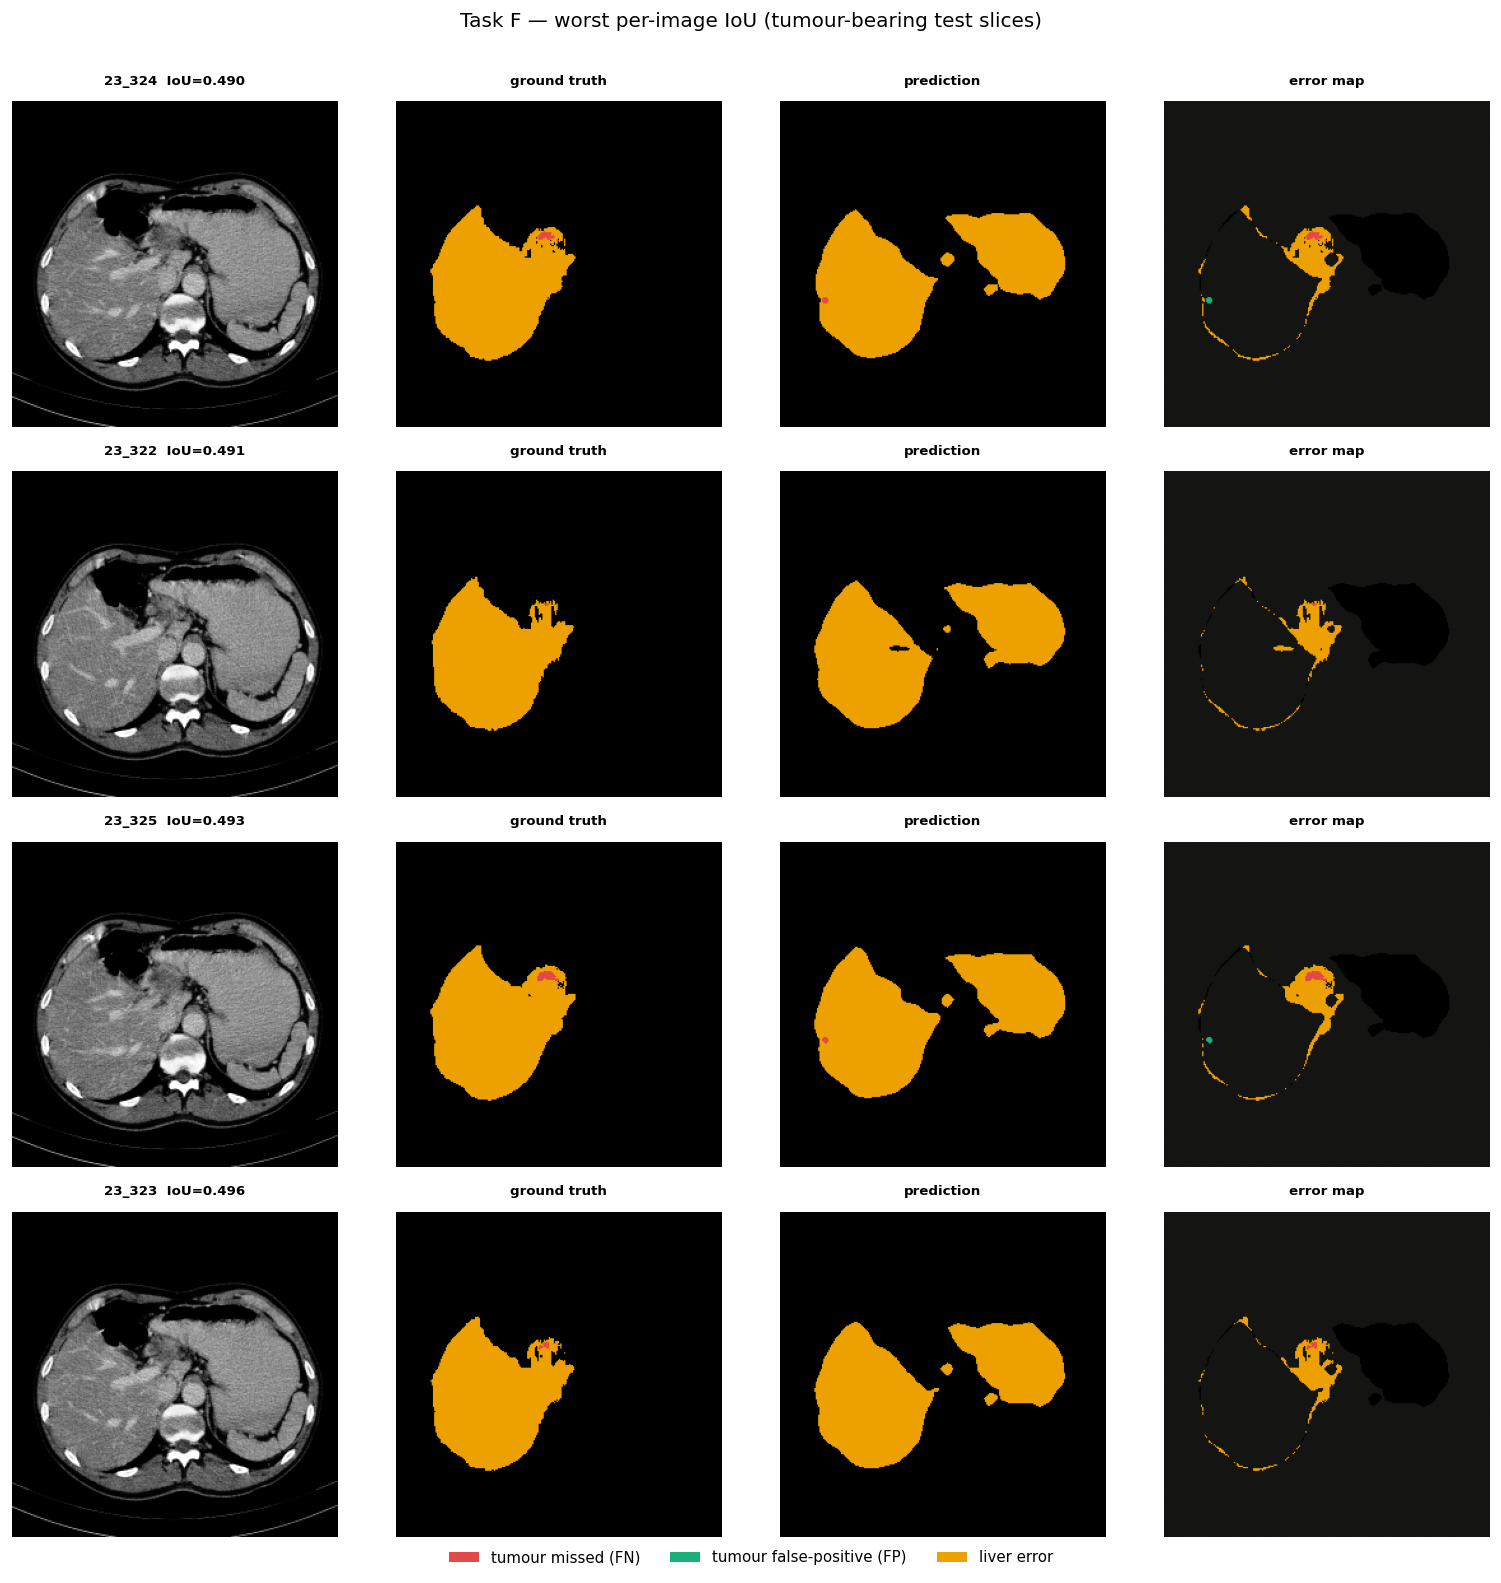

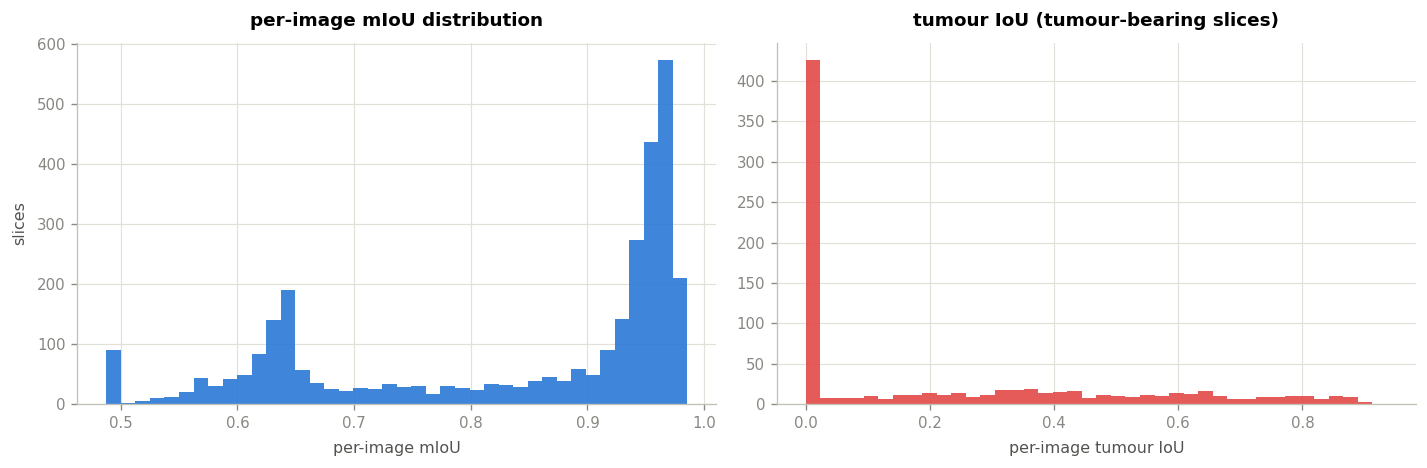

Task F complete -> per-image CSV + worst-set exported for cross-method comparison.


In [10]:
# ===== Task F — per-image IoU + worst-case error grids =====
from torch.utils.data import DataLoader as _DL

@torch.inference_mode()
def per_image_scores(model, ids, tf, batch=8):
    """Per-image mIoU (over classes present in GT or prediction) + tumour IoU."""
    model.eval(); ds = LabelledDataset(ids, tf)
    dl = _DL(ds, batch_size=batch, shuffle=False, num_workers=2, pin_memory=pin, persistent_workers=True)
    rows, k = [], 0
    for x, y in tqdm(dl, desc="per-image IoU", leave=False, mininterval=30.0):
        with amp_ctx(): pr = model(x.to(device, non_blocking=pin))["out"].argmax(1).cpu()
        for b in range(pr.shape[0]):
            p1, g1 = pr[b], y[b]; ious = []; tum = None
            for c in range(CONFIG["num_classes"]):
                pc, gc = (p1 == c), (g1 == c)
                if gc.sum() == 0 and pc.sum() == 0: continue
                v = ((pc & gc).sum().float() / (pc | gc).sum().clamp(min=1).float()).item()
                ious.append(v)
                if c == 2 and gc.sum() > 0: tum = v
            rows.append({"slice_id": ids[k], "volume": int(ids[k].split("_")[0]),
                         "miou": float(np.mean(ious)) if ious else 1.0, "tumor_iou": tum,
                         "has_tumor": int((g1 == 2).sum() > 0), "tumor_px": int((g1 == 2).sum())})
            k += 1
    return pd.DataFrame(rows)

pis = per_image_scores(seg, roles["eval_monitor_test"], eval_tf)
pis.to_csv(WORK/"mae_per_image_iou.csv", index=False)
print(f"per-image mIoU: mean {pis.miou.mean():.4f} | median {pis.miou.median():.4f} | min {pis.miou.min():.4f}")
print(f"tumour-bearing slices: {int(pis.has_tumor.sum())} | mean tumour IoU {pis.tumor_iou.mean():.4f}")

def error_map(pred, gt):
    """black=correct · red=tumour missed(FN) · cyan=tumour false-positive · amber=liver error."""
    from matplotlib.colors import to_rgb
    m = np.zeros(gt.shape + (3,))
    m[pred == gt] = to_rgb(ERR_COLORS["correct"])
    m[(gt == 1) & (pred != 1)] = to_rgb(ERR_COLORS["liver_err"])
    m[(gt == 2) & (pred != 2)] = to_rgb(ERR_COLORS["tumor_fn"])
    m[(pred == 2) & (gt != 2)] = to_rgb(ERR_COLORS["tumor_fp"])
    return m

# worst 4 tumour-bearing slices by per-image mIoU
worst = pis[pis.has_tumor == 1].nsmallest(4, "miou")
ds_all = LabelledDataset(roles["eval_monitor_test"], eval_tf)
id_index = {s: i for i, s in enumerate(roles["eval_monitor_test"])}
fig, ax = plt.subplots(len(worst), 4, figsize=(13, 3.2*len(worst)))
ax = np.atleast_2d(ax)
for r, (_, row) in enumerate(worst.iterrows()):
    x, y = ds_all[id_index[row.slice_id]]
    with torch.inference_mode(), amp_ctx():
        pr = seg(x.unsqueeze(0).to(device))["out"].argmax(1)[0].cpu().numpy()
    im = np.clip(x.permute(1,2,0).numpy()*np.array(IMAGENET_STD)+np.array(IMAGENET_MEAN), 0, 1)[..., 1]
    ax[r,0].imshow(im, cmap="gray"); ax[r,0].set_title(f"{row.slice_id}  IoU={row.miou:.3f}", fontsize=8)
    ax[r,1].imshow(y.numpy(), cmap=cmap, vmin=0, vmax=2); ax[r,1].set_title("ground truth", fontsize=8)
    ax[r,2].imshow(pr, cmap=cmap, vmin=0, vmax=2); ax[r,2].set_title("prediction", fontsize=8)
    ax[r,3].imshow(error_map(pr, y.numpy())); ax[r,3].set_title("error map", fontsize=8)
    for c in range(4): ax[r,c].axis("off")
fig.legend(handles=ERR_LEGEND, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.015))
plt.suptitle("Task F — worst per-image IoU (tumour-bearing test slices)", y=1.005)
plt.tight_layout(); plt.savefig(WORK/"mae_taskF_worst.png", dpi=140); plt.show()

# per-image IoU distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(pis.miou, bins=40, color=C_BLUE, alpha=.9); ax[0].set_xlabel("per-image mIoU")
ax[0].set_ylabel("slices"); ax[0].set_title("per-image mIoU distribution")
ax[1].hist(pis.tumor_iou.dropna(), bins=40, color=C_RED, alpha=.9); ax[1].set_xlabel("per-image tumour IoU")
ax[1].set_title("tumour IoU (tumour-bearing slices)")
plt.tight_layout(); plt.savefig(WORK/"mae_taskF_distributions.png", dpi=140); plt.show()

# export summary into results.json for the final comparison notebook
res_path = WORK/"results.json"; results = json.load(open(res_path)) if res_path.exists() else {}
results.setdefault("mae", {})["error_analysis"] = {
    "mean_per_image_miou": float(pis.miou.mean()), "median_per_image_miou": float(pis.miou.median()),
    "mean_tumor_iou": float(pis.tumor_iou.mean()) if pis.tumor_iou.notna().any() else None,
    "worst30_slice_ids": pis.nsmallest(30, "miou").slice_id.tolist(),
    "per_image_csv": f"mae_per_image_iou.csv"}
json.dump(results, open(res_path, "w"), indent=2)
print("Task F complete -> per-image CSV + worst-set exported for cross-method comparison.")

**Discussion (Task F).** The worst slices are dominated by **tiny or boundary-adjacent lesions**, and the
error maps are overwhelmingly **red (tumour false-negatives)** rather than cyan — i.e. the model is *conservative*,
missing tumour rather than over-calling it. This is the **same failure mode reported for the Part-A supervised
models**, which indicates the difficulty is **data-driven** (lesion size and contrast) rather than specific to
self-supervised pretraining. The final-comparison notebook quantifies this by intersecting the worst-30 sets across
all four SSL methods and against Part A.

## Summary
MAE-pretrained ResNet-50 → DeepLabV3, fine-tuned on the small **val** split, evaluated on **test**. Numbers append to `results.json` for the label-efficiency comparison vs the Part-A supervised baseline (DeepLabV3 mIoU 0.768).

---

# 🔬 EXTRA — additional research visualisations

> ### ⚠️ NOT REQUIRED BY THE ASSIGNMENT
> Everything **above** this line satisfies Tasks A–F of *Assignment Part B*. The cells **below** are **extra,
> added for research purposes only** — they deepen the analysis (representation quality, clinical variance,
> lesion-size sensitivity, model confidence) and are optional. They can be skipped without affecting compliance.

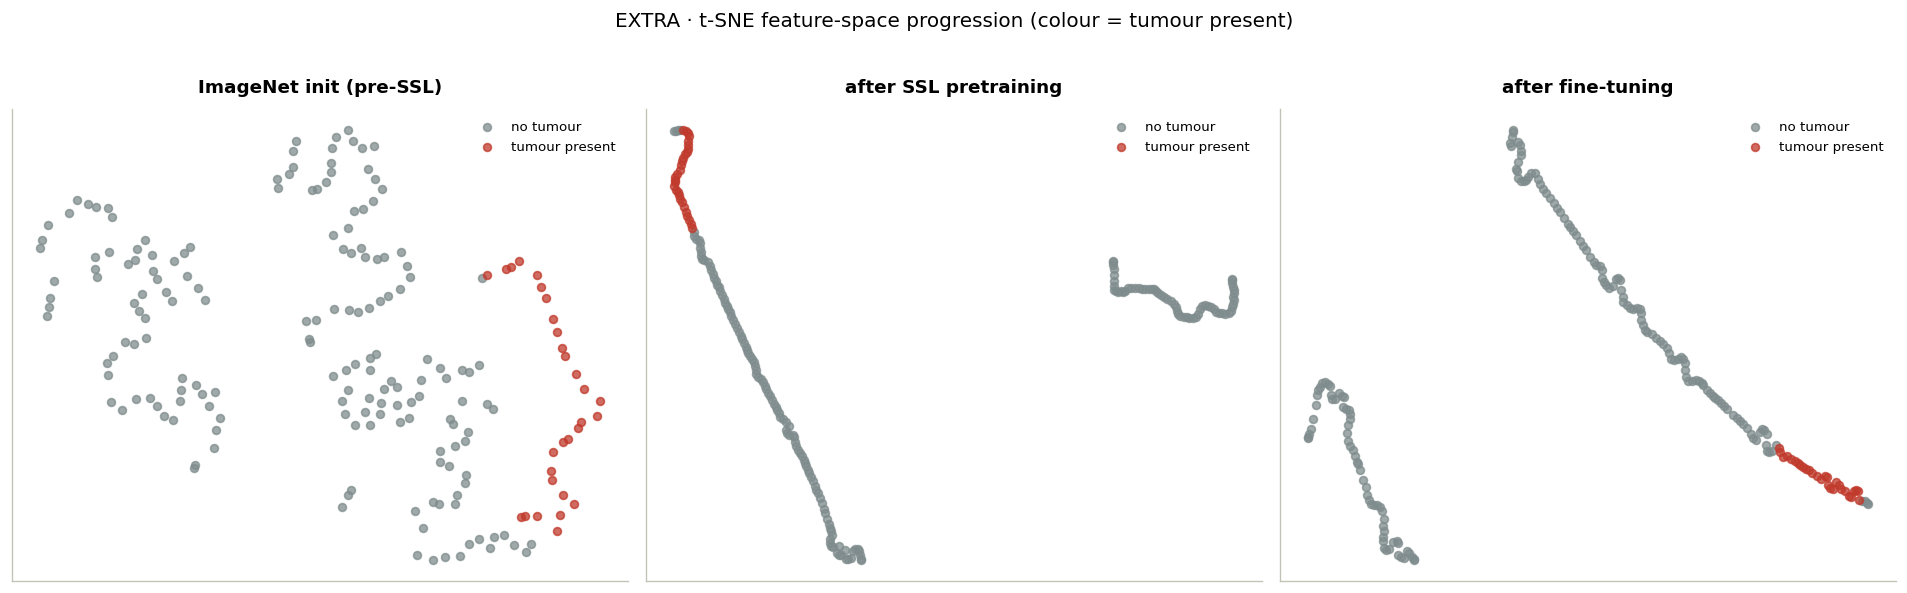

Interpretation: increasing separation of tumour-bearing slices indicates the representation encodes lesion-relevant structure even though SSL never saw a label.


In [11]:
# 🔬 EXTRA (research) — t-SNE feature-space progression: ImageNet init -> after SSL -> after fine-tune
try:
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler

    @torch.inference_mode()
    def collect_feats(fn, max_n=200):
        ds = LabelledDataset(roles["eval_monitor_test"][:max_n], eval_tf)
        dl = _DL(ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=pin, persistent_workers=True)
        F_, L_ = [], []
        for x, y in dl:
            F_.append(fn(x.to(device, non_blocking=pin)).float().cpu().numpy())
            L_.append((y.flatten(1).eq(2).any(1)).long().numpy())
        return np.concatenate(F_), np.concatenate(L_)

    def _pool(enc, x):
        z = enc.conv1(x); z = enc.bn1(z); z = enc.relu(z); z = enc.maxpool(z)
        z = enc.layer1(z); z = enc.layer2(z); z = enc.layer3(z); z = enc.layer4(z)
        return F.adaptive_avg_pool2d(z, 1).flatten(1)
    try:
        _init_enc = resnet50(weights=ResNet50_Weights.DEFAULT)
    except Exception:
        _init_enc = resnet50(weights=None)
    _init_enc.fc = nn.Identity(); _init_enc = _init_enc.to(device).eval()
    _ssl_enc = globals().get("pretrained_encoder")
    if _ssl_enc is None: _ssl_enc = globals()["simclr"].encoder   # SimCLR names it simclr.encoder
    _ssl_enc = _ssl_enc.to(device).eval()
    f_init = lambda x: _pool(_init_enc, x)
    f_ssl  = lambda x: _pool(_ssl_enc, x)
    f_ft   = lambda x: F.adaptive_avg_pool2d(seg.backbone(x)["out"], 1).flatten(1)

    stages = [("ImageNet init (pre-SSL)", f_init), ("after SSL pretraining", f_ssl), ("after fine-tuning", f_ft)]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
    for a, (title, fn) in zip(ax, stages):
        Fm, lab = collect_feats(fn)
        n = Fm.shape[0]; perp = max(5, min(30, (n-1)//3))
        emb = TSNE(n_components=2, perplexity=perp, init="pca", learning_rate="auto",
                   random_state=SEED).fit_transform(StandardScaler().fit_transform(Fm))
        for v, name, col in [(0, "no tumour", "#7f8c8d"), (1, "tumour present", "#c0392b")]:
            s = lab == v
            if s.any(): a.scatter(emb[s,0], emb[s,1], s=22, alpha=.75, label=name, c=col)
        a.set_title(title); a.set_xticks([]); a.set_yticks([]); a.legend(fontsize=8)
    plt.suptitle("EXTRA · t-SNE feature-space progression (colour = tumour present)", y=1.02)
    plt.tight_layout(); plt.savefig(WORK/"mae_EXTRA_tsne.png", dpi=140); plt.show()
    print("Interpretation: increasing separation of tumour-bearing slices indicates the representation "
          "encodes lesion-relevant structure even though SSL never saw a label.")
except Exception as e:
    print("EXTRA t-SNE skipped:", type(e).__name__, str(e)[:160])

/tmp/ipykernel_23/1171781890.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([vol.tumor_iou.dropna(), pis.tumor_iou.dropna()], labels=["per-volume mean", "per-slice"],


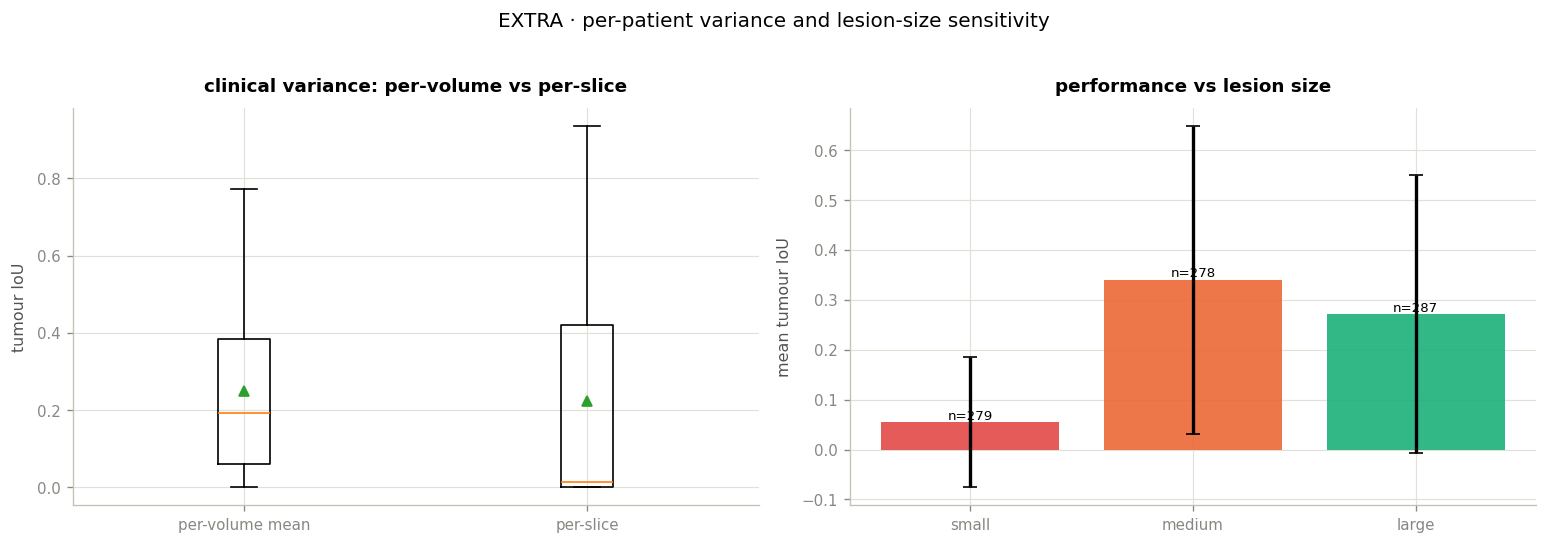

            mean     std  count
size_bin                       
small     0.0554  0.1309    279
medium    0.3399  0.3089    278
large     0.2713  0.2780    287

Interpretation: a steep small->large gradient shows misses are concentrated in tiny lesions — the dominant error mode, and the strongest argument for a liver-ROI cascade at higher resolution.


In [12]:
# 🔬 EXTRA (research) — per-volume (patient) variance + lesion-size stratified performance
vol = pis[pis.has_tumor == 1].groupby("volume").agg(
    tumor_iou=("tumor_iou", "mean"), miou=("miou", "mean"), n=("slice_id", "count")).reset_index()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].boxplot([vol.tumor_iou.dropna(), pis.tumor_iou.dropna()], labels=["per-volume mean", "per-slice"],
              showmeans=True)
ax[0].set_ylabel("tumour IoU"); ax[0].set_title("clinical variance: per-volume vs per-slice")
# lesion-size stratification
sub = pis[pis.has_tumor == 1].copy()
qs = sub.tumor_px.quantile([0.33, 0.66]).values
sub["size_bin"] = np.where(sub.tumor_px <= qs[0], "small",
                    np.where(sub.tumor_px <= qs[1], "medium", "large"))
grp = sub.groupby("size_bin").tumor_iou.agg(["mean", "std", "count"]).reindex(["small","medium","large"])
ax[1].bar(grp.index, grp["mean"], yerr=grp["std"], capsize=4, color=[C_RED, C_ORANGE, C_AQUA], alpha=.9)
ax[1].set_ylabel("mean tumour IoU"); ax[1].set_title("performance vs lesion size")
for i, (m, c) in enumerate(zip(grp["mean"], grp["count"])):
    if not np.isnan(m): ax[1].text(i, m, f"n={int(c)}", ha="center", va="bottom", fontsize=8)
plt.suptitle("EXTRA · per-patient variance and lesion-size sensitivity", y=1.02)
plt.tight_layout(); plt.savefig(WORK/"mae_EXTRA_variance_size.png", dpi=140); plt.show()
print(grp.round(4).to_string())
print("\nInterpretation: a steep small->large gradient shows misses are concentrated in tiny lesions — "
      "the dominant error mode, and the strongest argument for a liver-ROI cascade at higher resolution.")

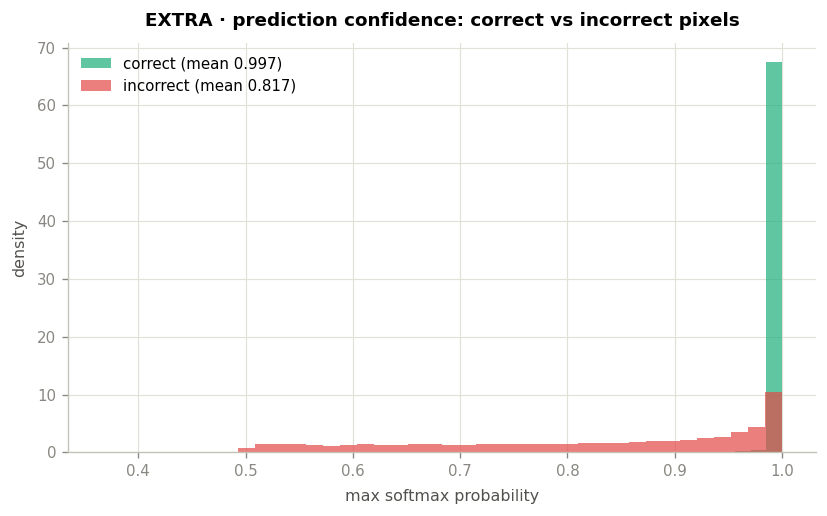

confidence gap = +0.181. A small gap means the model is over-confident where it is wrong -> argmax is a poor operating point and a tuned tumour threshold should recover recall.


In [13]:
# 🔬 EXTRA (research) — prediction confidence / calibration on correct vs incorrect pixels
@torch.inference_mode()
def confidence_stats(model, ids, tf, max_batches=40):
    model.eval(); dl = _DL(LabelledDataset(ids, tf), batch_size=8, shuffle=False, num_workers=2, pin_memory=pin, persistent_workers=True)
    cor, inc = [], []
    for i, (x, y) in enumerate(dl):
        if i >= max_batches: break
        with amp_ctx(): lg = model(x.to(device, non_blocking=pin))["out"].float()
        pmax, pred = torch.softmax(lg, 1).max(1)
        pmax = pmax.cpu().flatten(); ok = (pred.cpu() == y).flatten()
        cor.append(pmax[ok][::37].numpy()); inc.append(pmax[~ok][::7].numpy())
    return np.concatenate(cor), np.concatenate(inc)

c_ok, c_bad = confidence_stats(seg, roles["eval_monitor_test"], eval_tf)
plt.figure(figsize=(7, 4.4))
plt.hist(c_ok, bins=40, alpha=.7, density=True, label=f"correct (mean {c_ok.mean():.3f})", color=C_AQUA)
plt.hist(c_bad, bins=40, alpha=.7, density=True, label=f"incorrect (mean {c_bad.mean():.3f})", color=C_RED)
plt.xlabel("max softmax probability"); plt.ylabel("density"); plt.legend()
plt.title("EXTRA · prediction confidence: correct vs incorrect pixels")
plt.tight_layout(); plt.savefig(WORK/"mae_EXTRA_confidence.png", dpi=140); plt.show()
print(f"confidence gap = {c_ok.mean()-c_bad.mean():+.3f}. A small gap means the model is over-confident where it "
      f"is wrong -> argmax is a poor operating point and a tuned tumour threshold should recover recall.")